# Baselines
Multimodal Workflow Cost Estimator.

In [1]:
import pandas as pd
import os
import math

In [2]:
from data_loading import load_latency_data

In [3]:
from constants import DEFAULT_WORKFLOW_CONFIG

In [4]:
data_dir = "data/"
results_dir = "results/"

In [5]:
os.makedirs(results_dir, exist_ok=True)

## Workflow Config and Model Profiles

In [6]:
# StreamCast: Podcast generation
# for a 10 minute / 600 seconds video
workflow_config = DEFAULT_WORKFLOW_CONFIG

In [7]:
latency_data = load_latency_data(data_dir=data_dir)

## Multi-Requests

In [8]:
import pandas as pd

from sim_types import GPUType
from sim_types import Model

from multirequests import get_time_per_request_baseline
from multirequests import get_replicas
from multirequests import get_costs
from multirequests import QPM_LIST
from multirequests import INIT_REPLICAS_BASELINE

from data_loading import load_latency_data

from workflows import PODCAST_WORKFLOW

from constants import GPU_RESERVED_COST

In [9]:
data_dir = "data/"

In [10]:
latency_data = load_latency_data(data_dir=data_dir)

time_per_req_baseline = get_time_per_request_baseline(
    workflow_config=PODCAST_WORKFLOW,
    latency_data=latency_data,
    init_replicas=INIT_REPLICAS_BASELINE,
)

total_time_per_req = 0
for gpu_type in time_per_req_baseline:
    for model in time_per_req_baseline[gpu_type]:
        total_time_per_req += time_per_req_baseline[gpu_type][model]

In [11]:
print("Initial replicas (8 A100 baseline setup):")
for gpu_type, gpu_replicas in INIT_REPLICAS_BASELINE.items():
    print(f"  {gpu_type.value}:")
    for component, model_replicas in gpu_replicas.items():
        print(f"    {component.value}: {model_replicas}")

Initial replicas (8 A100 baseline setup):
  A100:
    others: 1
    gemma: 1
    flux: 1
    hf: 1
    ft: 4
  H100:


In [12]:
replicas_baseline = get_replicas(
    video_seconds= 10 * 60,
    time_per_req=time_per_req_baseline,
    init_replicas=INIT_REPLICAS_BASELINE,
)

costs_baseline = get_costs(
    replicas=replicas_baseline,
    gpu_costs=GPU_RESERVED_COST,
)

In [13]:
print("Per-hour Cost for each component based on required replicas (Naive Baseline A100 - FCFS)")
df_costs_baseline = pd.DataFrame(costs_baseline[GPUType.A100])
df_costs_baseline["Total"] = df_costs_baseline.sum(axis=1)
df_costs_baseline.index.name = "QPM"
df_costs_baseline.rename(columns={
    Model.OTHERS: "Kokoro ($)",
    Model.GEMMA: "Gemma ($)",
    Model.FLUX: "Flux ($)",
    Model.HF: "HF+VAE ($)",
    Model.FT: "FantasyTalking ($)",
    "Total": "Total ($)",
})

Per-hour Cost for each component based on required replicas (Naive Baseline A100 - FCFS)


,Kokoro ($),Gemma ($),Flux ($),HF+VAE ($),FantasyTalking ($),Total ($)
QPM,,,,,,
0,3.4,3.4,3.4,44.2,513.4,567.8
1,3.4,3.4,3.4,414.8,5117.0,5542.0
2,3.4,6.8,3.4,829.6,10230.6,11073.8
3,10.2,10.2,3.4,2074.0,25574.8,27672.6
4,17.0,20.4,6.8,4148.0,51149.6,55341.8
5,30.6,37.4,13.6,8292.6,102299.2,110673.4
6,44.2,54.4,17.0,12440.6,153448.8,166005.0
7,74.8,91.8,30.6,20733.2,255748.0,276678.4
8,146.2,180.2,57.8,41463.0,511492.6,553339.8


In [14]:
# Output results to DataFrame and CSV
df_costs_baseline.rename(columns={
    Model.OTHERS: "Kokoro ($)",
    Model.GEMMA: "Gemma ($)",
    Model.FLUX: "Flux ($)",
    Model.HF: "HF+VAE ($)",
    Model.FT: "FantasyTalking ($)",
    "Total": "Total ($)",
})

# Save to CSV (optional, uncomment if needed)
# df_multi_req_cost_baseline.to_csv("results/baseline/multi_req_cost_naive_baseline_fcfs.csv", index=False)

,Kokoro ($),Gemma ($),Flux ($),HF+VAE ($),FantasyTalking ($),Total ($)
QPM,,,,,,
0,3.4,3.4,3.4,44.2,513.4,567.8
1,3.4,3.4,3.4,414.8,5117.0,5542.0
2,3.4,6.8,3.4,829.6,10230.6,11073.8
3,10.2,10.2,3.4,2074.0,25574.8,27672.6
4,17.0,20.4,6.8,4148.0,51149.6,55341.8
5,30.6,37.4,13.6,8292.6,102299.2,110673.4
6,44.2,54.4,17.0,12440.6,153448.8,166005.0
7,74.8,91.8,30.6,20733.2,255748.0,276678.4
8,146.2,180.2,57.8,41463.0,511492.6,553339.8


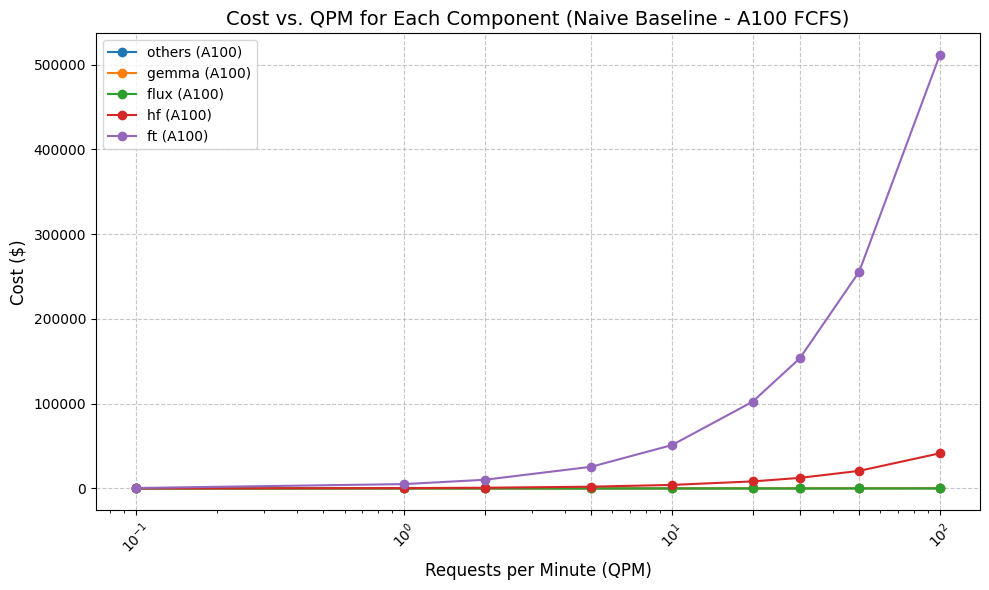

In [15]:
import matplotlib.pyplot as plt

# Plot cost vs QPM for each component (Naive Baseline - FCFS)
plt.figure(figsize=(10, 6))
for gpu_type in costs_baseline.keys():
    for model in costs_baseline[gpu_type].keys():
        plt.plot(QPM_LIST, costs_baseline[gpu_type][model], marker='o', label=f'{model.value} ({gpu_type.value})')

plt.xscale('log')

plt.xlabel('Requests per Minute (QPM)', fontsize=12)
plt.ylabel('Cost ($)', fontsize=12)
plt.title('Cost vs. QPM for Each Component (Naive Baseline - A100 FCFS)', fontsize=14)

plt.xticks(QPM_LIST, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## SLO Categories

In [16]:
# Model three request categories with different SLO requirements
# Each category has 1/3 of total requests
# 1. Tight SLO: Must meet baseline time (100% of total_time_per_req)
# 2. Relaxed SLO: Can take 50% longer (150% of total_time_per_req)
# 3. Batch (no SLO): No time constraints

# SLO relaxation factor
slo_relaxation_factor = 0.5  # 50% relaxation

# Define SLO categories
slo_categories = {
    "tight": {
        "fraction": 1/3,
        "slo_multiplier": 1.0,  # Must complete in baseline time
        "description": "Tight SLO (100% of baseline)"
    },
    "relaxed": {
        "fraction": 1/3,
        "slo_multiplier": 1.0 + slo_relaxation_factor,  # Can take 50% longer
        "description": f"Relaxed SLO ({int((1 + slo_relaxation_factor)*100)}% of baseline)"
    },
    "batch": {
        "fraction": 1/3,
        "slo_multiplier": float('inf'),  # No SLO constraint
        "description": "Batch (no SLO)"
    }
}

print("=== SLO Category Configuration ===")
for category, config in slo_categories.items():
    print(f"{category.capitalize()}: {config['description']}")
    print(f"  Fraction of requests: {config['fraction']:.2%}")
    if config['slo_multiplier'] != float('inf'):
        print(f"  Allowed time: {config['slo_multiplier']:.1f}x baseline time = {config['slo_multiplier'] * total_time_per_req:.2f}s")
    else:
        print(f"  Allowed time: No constraint")
    print()

=== SLO Category Configuration ===
Tight: Tight SLO (100% of baseline)
  Fraction of requests: 33.33%
  Allowed time: 1.0x baseline time = 29949.86s

Relaxed: Relaxed SLO (150% of baseline)
  Fraction of requests: 33.33%
  Allowed time: 1.5x baseline time = 44924.80s

Batch: Batch (no SLO)
  Fraction of requests: 33.33%
  Allowed time: No constraint



In [17]:
# NAIVE FCFS: All requests treated equally regardless of SLO
# Since FCFS is SLO-unaware, replicas needed are same as before
# (already calculated in previous cells as replicas_*_baseline)

# However, we need to check if tight SLO requests can meet their deadlines
# In FCFS, average waiting time increases linearly with load
# For tight SLO requests to meet deadlines, we need enough capacity

replicas_naive_slo: dict[GPUType, dict[Model, list[float]]] = {}

for qpm in QPM_LIST:
    arrival_rate = qpm / 60
    
    # In FCFS with mixed SLOs, we must provision for tight SLO (worst case)
    # Tight SLO requests (1/3 of traffic) must complete within total_time_per_req
    # Relaxed and batch requests can wait longer, but tight cannot
    # So we provision based on tight SLO requirements
    
    tight_arrival_rate = arrival_rate * slo_categories["tight"]["fraction"]
    
    # For tight SLO in FCFS: need replicas = arrival_rate * service_time / target_utilization
    # Using 0.9 utilization to keep queue manageable
    target_utilization = 0.9
    
    for gpu_type in time_per_req_baseline.keys():
        if gpu_type not in replicas_naive_slo:
            replicas_naive_slo[gpu_type] = {}
        for model in time_per_req_baseline[gpu_type].keys():
            # TODO model HF+VAE combined
            if model not in replicas_naive_slo[gpu_type]:
                replicas_naive_slo[gpu_type][model] = []
            replica_naive_slo = max(1, math.ceil(arrival_rate * time_per_req_baseline[gpu_type][model] / target_utilization))
            replicas_naive_slo[gpu_type][model].append(replica_naive_slo)

In [18]:
print("Naive FCFS Replicas (SLO-unaware, provisioned for tight SLO) ===")
df_replicas_naive_slo = pd.DataFrame(
    replicas_naive_slo[GPUType.A100],
)
df_replicas_naive_slo.index.name = "QPM"
df_replicas_naive_slo["Total"] = df_replicas_naive_slo.sum(axis=1)
df_replicas_naive_slo.rename(columns={
    Model.OTHERS: "Kokoro",
    Model.GEMMA: "Gemma",
    Model.FLUX: "Flux",
    Model.HF: "HF+VAE",
    Model.FT: "FantasyTalking",
})

Naive FCFS Replicas (SLO-unaware, provisioned for tight SLO) ===


,Kokoro,Gemma,Flux,HF+VAE,FantasyTalking,Total
QPM,,,,,,
0,1,1,1,14,42,59
1,1,1,1,136,418,557
2,1,2,1,271,836,1111
3,3,3,1,678,2090,2775
4,5,6,2,1355,4179,5547
5,10,12,4,2710,8358,11094
6,15,18,6,4065,12537,16641
7,24,30,10,6775,20895,27734
8,48,59,19,13550,41789,55465


In [19]:
# DEADLINE-AWARE: Prioritizes tight SLO requests
# Key insight: Relaxed and batch requests can tolerate longer wait times
# So we can provision less aggressively by serving tight SLO first

replicas_deadline_aware: dict[GPUType, dict[Model, list[float]]] = {}

for qpm in QPM_LIST:
    arrival_rate = qpm / 60
    
    # Split traffic by category
    tight_arrival = arrival_rate * slo_categories["tight"]["fraction"]
    relaxed_arrival = arrival_rate * slo_categories["relaxed"]["fraction"]
    batch_arrival = arrival_rate * slo_categories["batch"]["fraction"]
    
    # Deadline-aware scheduling: tight SLO gets priority
    # Tight SLO: needs full capacity (must complete quickly)
    # Relaxed SLO: can use 1.5x longer, so effectively 1/1.5 = 0.67x capacity needed
    # Batch: no SLO, can use spare capacity
    
    # Effective arrival rate accounting for different SLOs
    # Tight requests need immediate service, relaxed can wait longer
    relaxed_multiplier = 1.0 / slo_categories["relaxed"]["slo_multiplier"]
    
    effective_arrival = \
        tight_arrival + \
        (relaxed_arrival * relaxed_multiplier) + \
        (batch_arrival * 0.3)  # Batch uses leftover capacity
    
    # Provision based on effective arrival rate with higher utilization (0.95) 
    # since deadline-aware scheduling is more efficient
    target_utilization = 0.95

    # replicas_deadline_aware = {}
    for gpu_type in time_per_req_baseline.keys():
        if gpu_type not in replicas_deadline_aware:
            replicas_deadline_aware[gpu_type] = {}
        for model in time_per_req_baseline[gpu_type].keys():
            if model not in replicas_deadline_aware[gpu_type]:
                replicas_deadline_aware[gpu_type][model] = []
            num_replicas = max(1, math.ceil(effective_arrival * time_per_req_baseline[gpu_type][model] / target_utilization))
            replicas_deadline_aware[gpu_type][model].append(num_replicas)

In [20]:
print("Deadline-Aware Replicas (Prioritizes tight SLO)")
df_replicas_deadline_aware = pd.DataFrame(
    replicas_deadline_aware[GPUType.A100],
)
df_replicas_deadline_aware.index.name = "QPM"
df_replicas_deadline_aware["Total"] = df_replicas_deadline_aware.sum(axis=1)
df_replicas_deadline_aware.rename(columns={
    Model.OTHERS: "Kokoro",
    Model.GEMMA: "Gemma",
    Model.FLUX: "Flux",
    Model.HF: "HF+VAE",
    Model.FT: "FantasyTalking",
})

Deadline-Aware Replicas (Prioritizes tight SLO)


,Kokoro,Gemma,Flux,HF+VAE,FantasyTalking,Total
QPM,,,,,,
0,1,1,1,9,26,38
1,1,1,1,85,260,348
2,1,1,1,169,520,692
3,2,2,1,421,1298,1724
4,3,4,2,842,2596,3447
5,6,8,3,1684,5191,6892
6,9,11,4,2525,7786,10335
7,15,19,6,4208,12977,17225
8,30,37,12,8416,25953,34448


In [21]:
# Calculate costs
df_costs_baseline

costs_naive_slo = get_costs(
    replicas=replicas_naive_slo,
    gpu_costs=GPU_RESERVED_COST,
)
df_costs_naive_slo = pd.DataFrame(costs_naive_slo[GPUType.A100])

costs_deadline_aware = get_costs(
    replicas=replicas_deadline_aware,
    gpu_costs=GPU_RESERVED_COST,
)
df_costs_deadline_aware = pd.DataFrame(costs_deadline_aware[GPUType.A100])

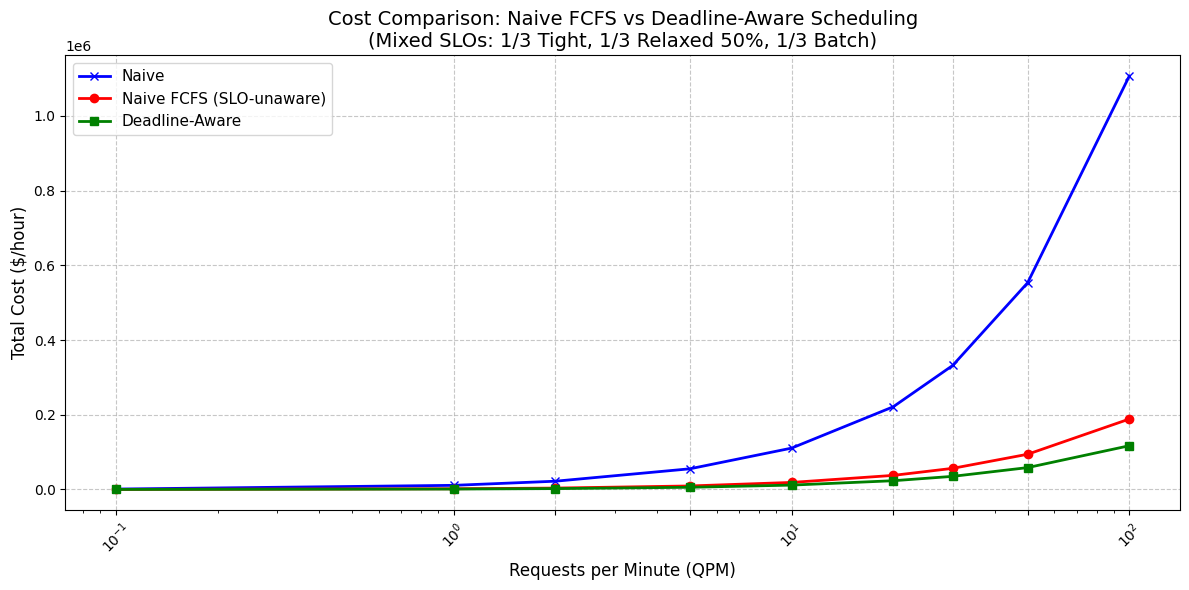

In [22]:
# Plot: Total Cost Comparison (Naive vs Deadline-Aware)
plt.figure(figsize=(12, 6))

plt.plot(
    QPM_LIST,
    df_costs_baseline.sum(axis=1).values,
    marker='x',
    linewidth=2,
    label='Naive',
    color='blue')
plt.plot(
    QPM_LIST,
    df_costs_naive_slo.sum(axis=1).values,
    marker='o',
    linewidth=2,
    label='Naive FCFS (SLO-unaware)',
    color='red')
plt.plot(
    QPM_LIST,
    df_costs_deadline_aware.sum(axis=1).values,
    marker='s',
    linewidth=2,
    label='Deadline-Aware',
    color='green')

plt.xscale('log')

plt.xlabel('Requests per Minute (QPM)', fontsize=12)
plt.ylabel('Total Cost ($/hour)', fontsize=12)
plt.title('Cost Comparison: Naive FCFS vs Deadline-Aware Scheduling\n(Mixed SLOs: 1/3 Tight, 1/3 Relaxed 50%, 1/3 Batch)', fontsize=14)

plt.xticks(QPM_LIST, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
# TODO this should be generated from previous cells
naive_costs = [  # Naive baseline
    567.8,
    5542.0,
    11070.4,
    27665.8,
    55328.2,
    110653.0,
    165977.8,
    276630.8,
    553251.4
]
sw_costs = [  # StreamWise
    687.6,
    1126.9,
    1985.8,
    4894.2,
    9759.4,
    19495.2,
    29231.3,
    48701.7,
    97395.8
]

df_costs_summary = pd.DataFrame({
    "QPM": QPM_LIST,
    "Naive ($)": df_costs_baseline.sum(axis=1),
    "SW Uniform ($)": df_costs_naive_slo.sum(axis=1),
    "SW Deadline ($)": df_costs_deadline_aware.sum(axis=1),
}).set_index("QPM")
df_costs_summary["Total reduction"] = (
    df_costs_summary["Naive ($)"] - df_costs_summary["SW Deadline ($)"]
) / df_costs_summary["Naive ($)"] * 100

df_costs_summary

,Naive ($),SW Uniform ($),SW Deadline ($),Total reduction
QPM,,,,
0.1,1135.6,200.6,129.2,88.622754
1.0,11084.0,1893.8,1183.2,89.325153
2.0,22147.6,3777.4,2352.8,89.376727
5.0,55345.2,9435.0,5861.6,89.409018
10.0,110683.6,18859.8,11719.8,89.411439
20.0,221346.8,37719.6,23432.8,89.413536
30.0,332010.0,56579.4,35139.0,89.416283
50.0,553356.8,94295.6,58565.0,89.416413
100.0,1106679.6,188581.0,117123.2,89.416702


In [24]:
"""
# Map the StreamCast uniform SLO costs to the deadline-aware scenario
# We need to apply the same ratio/factor from the naive FCFS -> deadline-aware calculation
# to the StreamCast uniform SLO costs to get the final StreamCast deadline-aware costs

# The deadline-aware optimization reduces costs because:
# 1. Tight SLO requests (1/3) need full provisioning
# 2. Relaxed SLO requests (1/3) can share resources better (50% relaxation)
# 3. Batch requests (1/3) have no SLO and can use spare capacity

# Calculate the improvement ratio from deadline-aware scheduling
# This is: (naive_slo_cost - deadline_cost) / naive_slo_cost
improvement_ratio = [
    (total_cost_naive_slo[i] - total_cost_deadline[i]) / total_cost_naive_slo[i] if total_cost_naive_slo[i] > 0 else 0
    for i in range(len(QPM_LIST))
]

# Apply this improvement ratio to the StreamCast uniform SLO costs
# to get the final StreamCast deadline-aware costs
streamcast_deadline_aware_costs = [
    sw_costs[i] * (1 - improvement_ratio[i])
    for i in range(len(QPM_LIST))
]

# Calculate the final cost reduction from naive baseline to StreamCast deadline-aware
final_cost_savings = [
    naive_costs[i] - streamcast_deadline_aware_costs[i]
    for i in range(len(QPM_LIST))
]

final_cost_savings_percent = [
    (final_cost_savings[i] / naive_costs[i] * 100) if naive_costs[i] > 0 else 0
    for i in range(len(QPM_LIST))
]

final_reduction_factor = [
    naive_costs[i] / streamcast_deadline_aware_costs[i] if streamcast_deadline_aware_costs[i] > 0 else 0
    for i in range(len(QPM_LIST))
]

# Also calculate the incremental improvement from StreamCast uniform to deadline-aware
incremental_savings = [
    sw_costs[i] - streamcast_deadline_aware_costs[i]
    for i in range(len(QPM_LIST))
]

incremental_savings_percent = [
    (incremental_savings[i] / sw_costs[i] * 100) if sw_costs[i] > 0 else 0
    for i in range(len(QPM_LIST))
]

print("\n=== Complete Cost Breakdown ===")
print(f"{'QPM':<10} {'Naive ($)':<15} {'SW Uniform ($)':<15} {'SW Deadline ($)':<15} {'Total Reduction':<20} {'Final Factor':<15}")
print("-" * 95)
for i, qpm in enumerate(QPM_LIST):
    print(f"{qpm:<10} {naive_costs[i]:<15.2f} {sw_costs[i]:<15.2f} {streamcast_deadline_aware_costs[i]:<15.2f} {final_cost_savings_percent[i]:<19.2f}% {final_reduction_factor[i]:<15.2f}x")

print("\n=== Average Cost Reduction ===")
avg_final_reduction = sum(final_cost_savings_percent) / len(final_cost_savings_percent)
avg_final_factor = sum(final_reduction_factor) / len(final_reduction_factor)
print(f"Average total cost reduction: {avg_final_reduction:.2f}%")
print(f"Average cost reduction factor: {avg_final_factor:.2f}x")
"""

'\n# Map the StreamCast uniform SLO costs to the deadline-aware scenario\n# We need to apply the same ratio/factor from the naive FCFS -> deadline-aware calculation\n# to the StreamCast uniform SLO costs to get the final StreamCast deadline-aware costs\n\n# The deadline-aware optimization reduces costs because:\n# 1. Tight SLO requests (1/3) need full provisioning\n# 2. Relaxed SLO requests (1/3) can share resources better (50% relaxation)\n# 3. Batch requests (1/3) have no SLO and can use spare capacity\n\n# Calculate the improvement ratio from deadline-aware scheduling\n# This is: (naive_slo_cost - deadline_cost) / naive_slo_cost\nimprovement_ratio = [\n    (total_cost_naive_slo[i] - total_cost_deadline[i]) / total_cost_naive_slo[i] if total_cost_naive_slo[i] > 0 else 0\n    for i in range(len(QPM_LIST))\n]\n\n# Apply this improvement ratio to the StreamCast uniform SLO costs\n# to get the final StreamCast deadline-aware costs\nstreamcast_deadline_aware_costs = [\n    sw_costs[i] * (

In [25]:
"""
# Visualization 2: Stacked bar chart showing incremental improvements
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(QPM_LIST))
width = 0.6

# Calculate the components for stacked bars
stage1_reduction = [naive_costs[i] - sw_costs[i] for i in range(len(QPM_LIST))]  # Naive → Uniform
stage2_reduction = incremental_savings  # Uniform → Deadline-Aware
remaining_cost = streamcast_deadline_aware_costs  # Final cost

# Create stacked bars
p1 = ax.bar(x, remaining_cost, width, label='Final Cost (StreamCast Deadline-Aware)', color='green', alpha=0.8)
p2 = ax.bar(x, stage2_reduction, width, bottom=remaining_cost, label='Deadline-Aware Savings', color='lightgreen', alpha=0.8)
bottom2 = [remaining_cost[i] + stage2_reduction[i] for i in range(len(QPM_LIST))]
p3 = ax.bar(x, stage1_reduction, width, bottom=bottom2, label='StreamCast Uniform SLO Savings', color='orange', alpha=0.8)

ax.set_xlabel('Requests per Minute (QPM)', fontsize=12)
ax.set_ylabel('Cost ($/hour)', fontsize=12)
ax.set_title('Cost Breakdown: Cumulative Savings from Multiple Optimizations', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(QPM_LIST)
ax.legend(fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add total cost labels on top of each bar
for i in x:
    total = naive_costs[i]
    ax.text(i, total + max(naive_costs) * 0.02, f'${total:.0f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
"""

"\n# Visualization 2: Stacked bar chart showing incremental improvements\nfig, ax = plt.subplots(figsize=(14, 7))\n\nx = range(len(QPM_LIST))\nwidth = 0.6\n\n# Calculate the components for stacked bars\nstage1_reduction = [naive_costs[i] - sw_costs[i] for i in range(len(QPM_LIST))]  # Naive → Uniform\nstage2_reduction = incremental_savings  # Uniform → Deadline-Aware\nremaining_cost = streamcast_deadline_aware_costs  # Final cost\n\n# Create stacked bars\np1 = ax.bar(x, remaining_cost, width, label='Final Cost (StreamCast Deadline-Aware)', color='green', alpha=0.8)\np2 = ax.bar(x, stage2_reduction, width, bottom=remaining_cost, label='Deadline-Aware Savings', color='lightgreen', alpha=0.8)\nbottom2 = [remaining_cost[i] + stage2_reduction[i] for i in range(len(QPM_LIST))]\np3 = ax.bar(x, stage1_reduction, width, bottom=bottom2, label='StreamCast Uniform SLO Savings', color='orange', alpha=0.8)\n\nax.set_xlabel('Requests per Minute (QPM)', fontsize=12)\nax.set_ylabel('Cost ($/hour)', fon